# Healthcare Analytics for Doctor Visits

**Goal:** understand what drives the number of doctor visits in a two-week survey window, and whether insurance type matters.

**Variables** (standard description of this Australian Health Survey dataset; the CSV itself has no data dictionary):

| Column | Meaning |
|---|---|
| `visits` | Doctor visits in the past 2 weeks |
| `gender` | Gender |
| `age` | Age in years / 100 (banded) |
| `income` | Annual income in units of 10,000 (banded) |
| `illness` | Number of illnesses in the past 2 weeks |
| `reduced` | Days of reduced activity in the past 2 weeks |
| `health` | General-health questionnaire score (**higher = worse health**) |
| `private` | Has private health insurance |
| `freepoor` | Free government cover because of low income |
| `freerepat` | Free government cover because of old age, disability or veteran status |
| `nchronic` | Chronic condition that is non-limiting |
| `lchronic` | Activity-limiting chronic condition |

In [36]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")

In [37]:
import pandas as pd
df = pd.read_csv("/content/1776250375-P2-Healthcare Analytics for Doctor Visits (1).csv", index_col=0)
print("Shape:", df.shape)
df.head()

Shape: (5190, 12)


,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
1,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
2,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
3,1,male,0.19,0.90,3,0,0,no,no,no,no,no
4,1,male,0.19,0.15,1,0,0,no,no,no,no,no
5,1,male,0.19,0.45,2,5,1,no,no,no,yes,no


In [38]:
df.tail()

,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
5186,0,female,0.22,0.55,0,0,0,no,no,no,no,no
5187,0,male,0.27,1.30,0,0,1,no,no,no,no,no
5188,0,female,0.37,0.25,1,0,1,no,no,yes,no,no
5189,0,female,0.52,0.65,0,0,0,no,no,no,no,no
5190,0,male,0.72,0.25,0,0,0,no,no,yes,no,no


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5190 entries, 1 to 5190
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   visits     5190 non-null   int64  
 1   gender     5190 non-null   object 
 2   age        5190 non-null   float64
 3   income     5190 non-null   float64
 4   illness    5190 non-null   int64  
 5   reduced    5190 non-null   int64  
 6   health     5190 non-null   int64  
 7   private    5190 non-null   object 
 8   freepoor   5190 non-null   object 
 9   freerepat  5190 non-null   object 
 10  nchronic   5190 non-null   object 
 11  lchronic   5190 non-null   object 
dtypes: float64(2), int64(4), object(6)
memory usage: 527.1+ KB


In [40]:
df.describe()

,visits,age,income,illness,reduced,health
count,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000
mean,0.301734,0.406385,0.583160,1.431985,0.861850,1.217534
std,0.798134,0.204782,0.368907,1.384152,2.887628,2.124266
min,0.000000,0.190000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.220000,0.250000,0.000000,0.000000,0.000000
50%,0.000000,0.320000,0.550000,1.000000,0.000000,0.000000
75%,0.000000,0.620000,0.900000,2.000000,0.000000,2.000000
max,9.000000,0.720000,1.500000,5.000000,14.000000,12.000000


In [41]:
print("Missing values:\n", df.isnull().sum())
n_dup = df.duplicated().sum()
print(f"\nIdentical rows (row-ID column excluded): {n_dup}")
print("-> Expected: age, income, illness etc. are coarse/banded survey answers, so different people")
print("   can have identical records. These are NOT true duplicates and are NOT removed.")
print("\nGender:", df['gender'].unique())
for col in ['private', 'freepoor', 'freerepat', 'nchronic', 'lchronic']:
    print(col, ':', df[col].unique())

Missing values:
 visits       0
gender       0
age          0
income       0
illness      0
reduced      0
health       0
private      0
freepoor     0
freerepat    0
nchronic     0
lchronic     0
dtype: int64

Identical rows (row-ID column excluded): 1320
-> Expected: age, income, illness etc. are coarse/banded survey answers, so different people
   can have identical records. These are NOT true duplicates and are NOT removed.

Gender: ['female' 'male']
private : ['yes' 'no']
freepoor : ['no' 'yes']
freerepat : ['no' 'yes']
nchronic : ['no' 'yes']
lchronic : ['no' 'yes']


In [42]:
df['age_years'] = (df['age'] * 100).round().astype(int)
df['income_dollars'] = (df['income'] * 10000).round().astype(int)
df['any_visit'] = (df['visits'] > 0).astype(int)
df['lchronic_num'] = (df['lchronic'] == 'yes').astype(int)   # 0/1 version, needed for correlations

bins = [18, 30, 45, 60, 75]
labels = ['19-30', '31-45', '46-60', '61-72']
df['age_group'] = pd.cut(df['age_years'], bins=bins, labels=labels, include_lowest=True)

print(df['age_group'].value_counts(sort=False))
df[['age_years', 'income_dollars', 'any_visit', 'age_group']].head()

age_group
19-30    2488
31-45     573
46-60     676
61-72    1453
Name: count, dtype: int64


,age_years,income_dollars,any_visit,age_group
1,19,5500,1,19-30
2,19,4500,1,19-30
3,19,9000,1,19-30
4,19,1500,1,19-30
5,19,4500,1,19-30


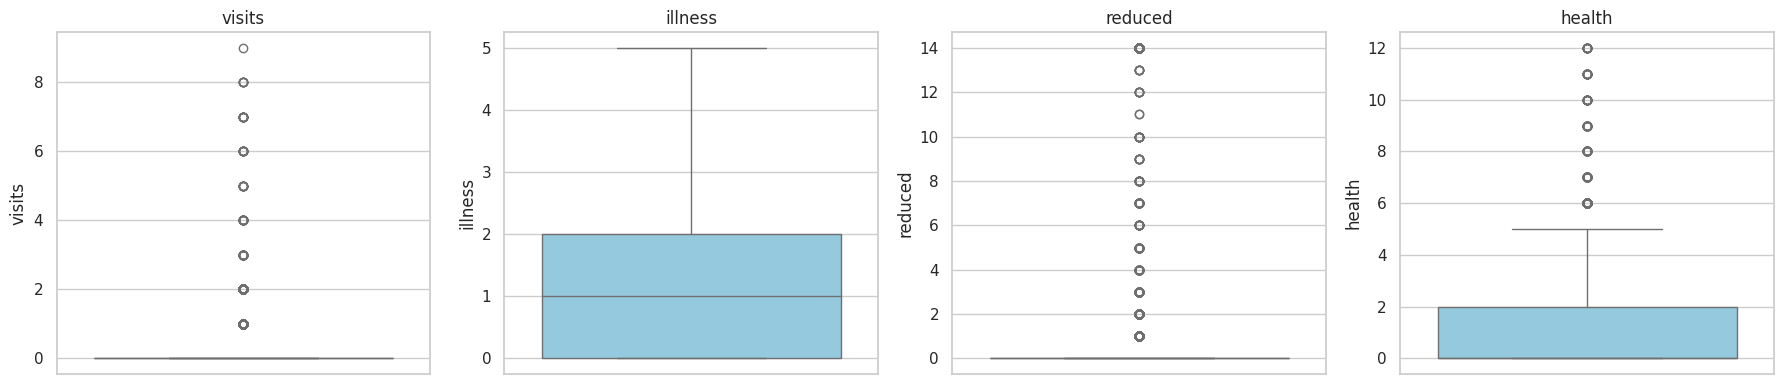

IQR-rule flags (NOT necessarily real outliers):
  visits: 1049 flagged (bounds: 0.0 to 0.0), share of zeros = 79.8%, max = 9
  illness: 0 flagged (bounds: -3.0 to 5.0), share of zeros = 29.9%, max = 5
  reduced: 736 flagged (bounds: 0.0 to 0.0), share of zeros = 85.8%, max = 14
  health: 303 flagged (bounds: -3.0 to 5.0), share of zeros = 58.3%, max = 12


In [43]:
outlier_cols = ['visits', 'illness', 'reduced', 'health']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, outlier_cols):
    sns.boxplot(y=df[col], ax=ax, color='skyblue')
    ax.set_title(col)
plt.tight_layout()
plt.show()

print("IQR-rule flags (NOT necessarily real outliers):")
for col in outlier_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"  {col}: {n_out} flagged (bounds: {lower:.1f} to {upper:.1f}), "
          f"share of zeros = {(df[col] == 0).mean():.1%}, max = {df[col].max()}")

**Reading this correctly:** `visits` and `reduced` are mostly zeros (80% and 86%), so Q1 = Q3 = 0. Because of this, the IQR rule marks every non-zero value as an outlier. These are real values, so I keep them.

##  Univariate Analysis

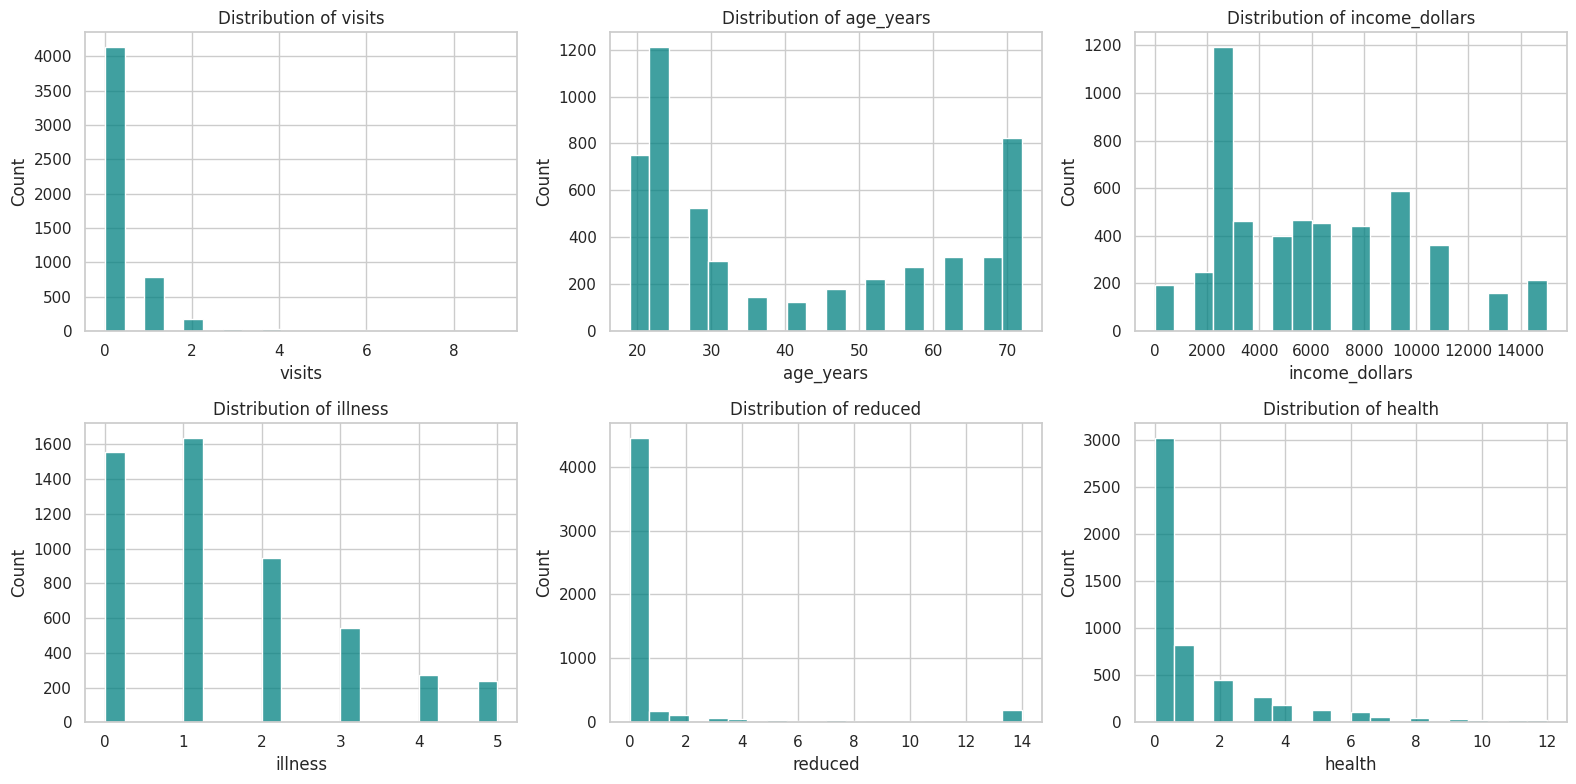

% of individuals with zero doctor visits: 79.8 %


In [44]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
uni_cols = ['visits', 'age_years', 'income_dollars', 'illness', 'reduced', 'health']
for ax, col in zip(axes.flatten(), uni_cols):
    sns.histplot(df[col], bins=20, kde=False, ax=ax, color='teal')
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

print("% of individuals with zero doctor visits:", round((df['visits'] == 0).mean() * 100, 1), "%")

### Gender

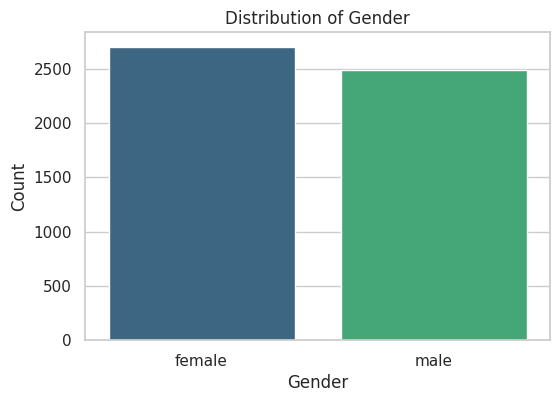

In [45]:
plt.figure(figsize=(6, 4))
sns.countplot(x='gender', data=df, palette='viridis', hue='gender', legend=False)
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

### Age

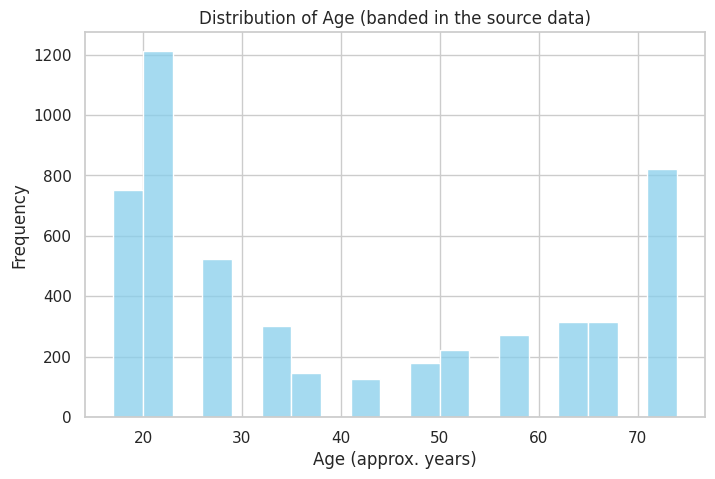

In [46]:
plt.figure(figsize=(8, 5))
sns.histplot(df['age_years'], bins=range(17, 76, 3), kde=False, color='skyblue')
plt.title('Distribution of Age (banded in the source data)')
plt.xlabel('Age (approx. years)')
plt.ylabel('Frequency')
plt.show()

### Doctor Visits

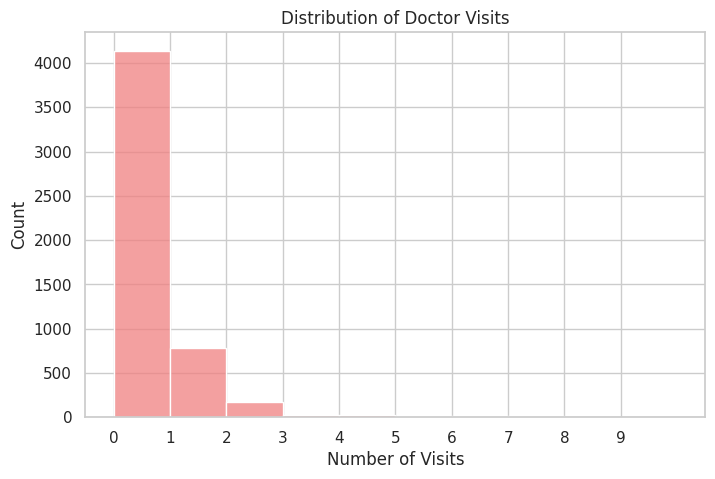

In [47]:
plt.figure(figsize=(8, 5))
sns.histplot(df['visits'], bins=range(int(df['visits'].max()) + 2), kde=False, color='lightcoral', stat='count')
plt.title('Distribution of Doctor Visits')
plt.xlabel('Number of Visits')
plt.ylabel('Count')
plt.xticks(range(int(df['visits'].max()) + 1))
plt.show()

##  Doctor Visits by Gender

gender
female    0.361954
male      0.236334
Name: visits, dtype: float64


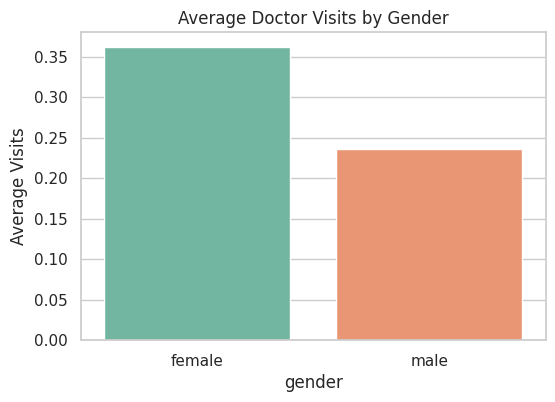

Welch t-test (female vs male visits): t = 5.72, p-value = 1.11e-08
Mann-Whitney U: p-value = 6.34e-15


In [48]:
gender_visits = df.groupby('gender')['visits'].mean()
print(gender_visits)

plt.figure(figsize=(6, 4))
sns.barplot(x=gender_visits.index, y=gender_visits.values, hue=gender_visits.index, palette='Set2', legend=False)
plt.title('Average Doctor Visits by Gender')
plt.ylabel('Average Visits')
plt.show()

f = df[df['gender'] == 'female']['visits']
m = df[df['gender'] == 'male']['visits']
t_stat, p_val = stats.ttest_ind(f, m, equal_var=False)
u_stat, p_mw = stats.mannwhitneyu(f, m, alternative='two-sided')
print(f"Welch t-test (female vs male visits): t = {t_stat:.2f}, p-value = {p_val:.2e}")
print(f"Mann-Whitney U: p-value = {p_mw:.2e}")

### Visit distribution shape by gender

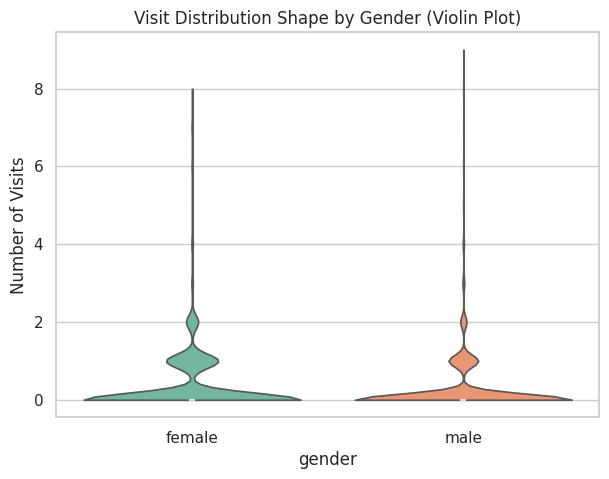

Median visits:
 gender
female    0.0
male      0.0
Name: visits, dtype: float64

Share with at least one visit:
 gender
female    0.244
male      0.156
Name: any_visit, dtype: float64


In [49]:
plt.figure(figsize=(7, 5))
sns.violinplot(x='gender', y='visits', data=df, palette='Set2', hue='gender', legend=False, cut=0)
plt.title('Visit Distribution Shape by Gender (Violin Plot)')
plt.ylabel('Number of Visits')
plt.show()

print("Median visits:\n", df.groupby('gender')['visits'].median())
print("\nShare with at least one visit:\n", df.groupby('gender')['any_visit'].mean().round(3))

### Is the gender gap explained by chronic conditions?
Women have a much higher rate of non-limiting chronic conditions (47.6% vs 32.4%) and a slightly higher rate of limiting ones (12.6% vs 10.7%), so the two groups are *not* identical in chronic status. Still, the gap remains inside every chronic-status group, so it is not explained by chronic status alone.

In [50]:
# Do men and women differ in chronic-condition rates? (needed before interpreting the gender gap)
print("Share with chronic condition, by gender:")
print(df.groupby('gender')[['nchronic', 'lchronic']].agg(lambda x: (x == 'yes').mean()).round(3))

# Does the gender gap survive within chronic-status groups?
print("\nMean visits by gender within chronic groups:")
print(df.groupby(['lchronic', 'gender'])['visits'].mean().unstack().round(3))
print(df.groupby(['nchronic', 'gender'])['visits'].mean().unstack().round(3))

Share with chronic condition, by gender:
        nchronic  lchronic
gender                    
female     0.476     0.126
male       0.324     0.107

Mean visits by gender within chronic groups:
gender    female   male
lchronic               
no         0.314  0.206
yes        0.694  0.487
gender    female   male
nchronic               
no         0.345  0.211
yes        0.381  0.290


##  Doctor Visits by Chronic Condition Status

                                 No Chronic Condition  Has Chronic Condition
Non-limiting chronic (nchronic)                 0.272                  0.346
Limiting chronic (lchronic)                     0.262                  0.603


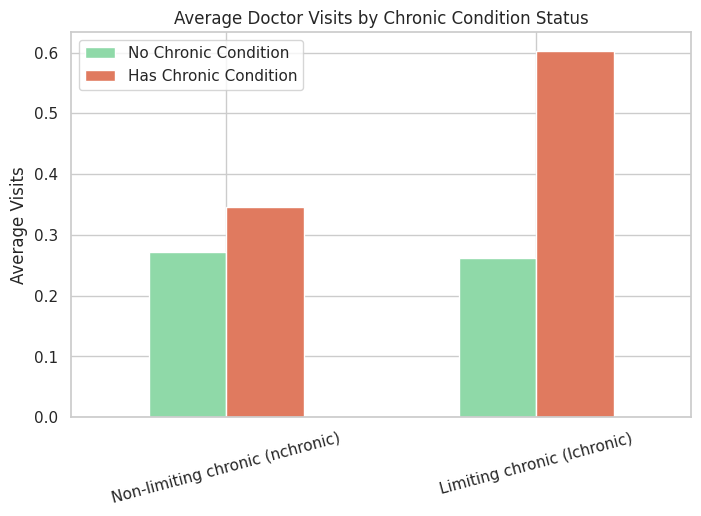

Welch t-test (nchronic yes vs no): t = 3.23, p-value = 1.24e-03, ratio of means = 1.27x
Welch t-test (lchronic yes vs no): t = 6.86, p-value = 1.55e-11, ratio of means = 2.30x


In [51]:
chronic_visits = pd.DataFrame({
    'No Chronic Condition': [df[df['nchronic'] == 'no']['visits'].mean(), df[df['lchronic'] == 'no']['visits'].mean()],
    'Has Chronic Condition': [df[df['nchronic'] == 'yes']['visits'].mean(), df[df['lchronic'] == 'yes']['visits'].mean()]
}, index=['Non-limiting chronic (nchronic)', 'Limiting chronic (lchronic)'])
print(chronic_visits.round(3))

chronic_visits.plot(kind='bar', figsize=(8, 5), color=['#8fd9a8', '#e07a5f'])
plt.title('Average Doctor Visits by Chronic Condition Status')
plt.ylabel('Average Visits')
plt.xticks(rotation=15)
plt.show()

for col in ['nchronic', 'lchronic']:
    a = df[df[col] == 'yes']['visits']
    b = df[df[col] == 'no']['visits']
    t_stat, p_val = stats.ttest_ind(a, b, equal_var=False)
    print(f"Welch t-test ({col} yes vs no): t = {t_stat:.2f}, p-value = {p_val:.2e}, "
          f"ratio of means = {a.mean() / b.mean():.2f}x")

##  Doctor Visits by Age Group

age_group
19-30    0.217
31-45    0.260
46-60    0.370
61-72    0.432
Name: visits, dtype: float64
Oldest / youngest ratio: 2.0


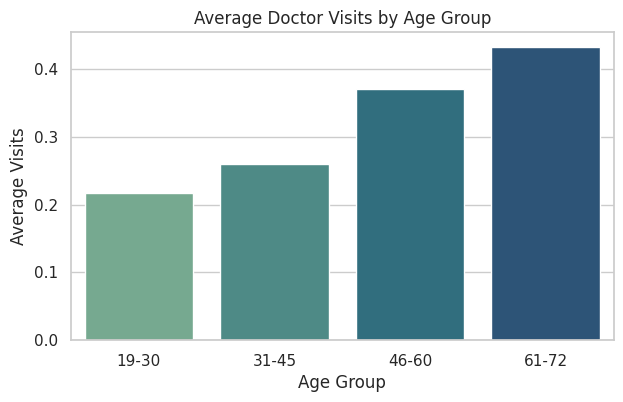

In [52]:
age_visits = df.groupby('age_group', observed=True)['visits'].mean()
print(age_visits.round(3))
print("Oldest / youngest ratio:", round(age_visits.iloc[-1] / age_visits.iloc[0], 2))

plt.figure(figsize=(7, 4))
sns.barplot(x=age_visits.index, y=age_visits.values, hue=age_visits.index, palette='crest', legend=False)
plt.title('Average Doctor Visits by Age Group')
plt.ylabel('Average Visits')
plt.xlabel('Age Group')
plt.show()

##  Illness, Reduced-Activity Days and Visits

### Reduced-activity days vs. illness count (strip plot)

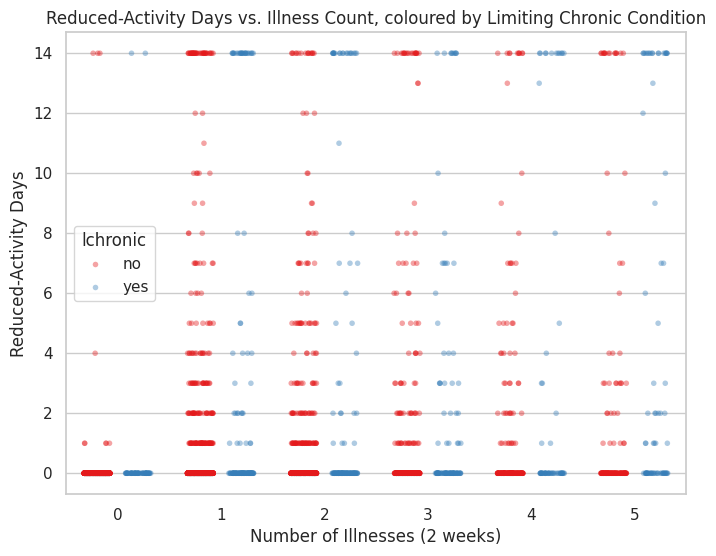

Average reduced-activity days by illness count and chronic status:
lchronic    no   yes
illness             
0         0.03  0.40
1         0.74  2.83
2         0.79  2.51
3         1.15  2.17
4         1.47  3.13
5         1.94  4.41


In [53]:
plt.figure(figsize=(8, 6))
sns.stripplot(x='illness', y='reduced', hue='lchronic', data=df, alpha=0.4, palette='Set1',
              dodge=True, jitter=0.25, size=4)
plt.title('Reduced-Activity Days vs. Illness Count, coloured by Limiting Chronic Condition')
plt.xlabel('Number of Illnesses (2 weeks)')
plt.ylabel('Reduced-Activity Days')
plt.show()

print("Average reduced-activity days by illness count and chronic status:")
print(df.groupby(['illness', 'lchronic'])['reduced'].mean().unstack().round(2))

### Illness score vs. average visits

   illness  count   mean
0        0   1554  0.079
1        1   1638  0.295
2        2    946  0.404
3        3    542  0.421
4        4    274  0.577
5        5    236  0.814


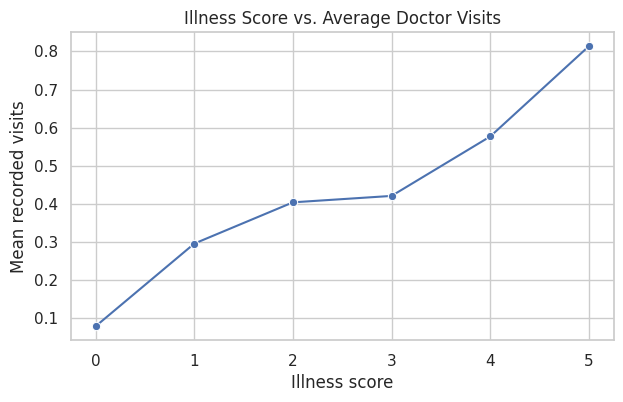

In [54]:
illness_analysis = df.groupby("illness")["visits"].agg(["count", "mean"]).reset_index()
print(illness_analysis.round(3))

plt.figure(figsize=(7, 4))
sns.lineplot(data=illness_analysis, x="illness", y="mean", marker="o")
plt.title("Illness Score vs. Average Doctor Visits")
plt.xlabel("Illness score")
plt.ylabel("Mean recorded visits")
plt.show()

##  Correlation Analysis
`reduced` (0.42) is by far the strongest single correlate of visits, followed by `illness` (0.22) and `health` (0.19). `lchronic_num` (0.14) and age (0.12) are similar in size to each other, and income is weakly negative (-0.08).

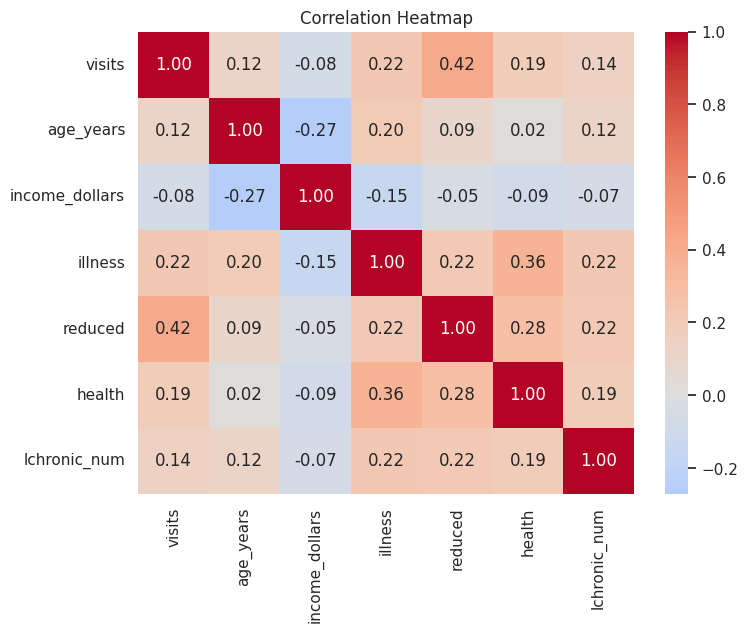

Correlation with visits, ranked:
 visits            1.000
reduced           0.419
illness           0.224
health            0.193
lchronic_num      0.137
age_years         0.125
income_dollars   -0.077
Name: visits, dtype: float64


In [55]:
num_cols = ['visits', 'age_years', 'income_dollars', 'illness', 'reduced', 'health', 'lchronic_num']
corr = df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

print("Correlation with visits, ranked:\n", corr['visits'].sort_values(ascending=False).round(3))

##  Does Private Insurance Increase Doctor Visits?

private
no     0.307
yes    0.295
Name: visits, dtype: float64
Welch t-test (private yes vs no): t = -0.58, p-value = 0.5636


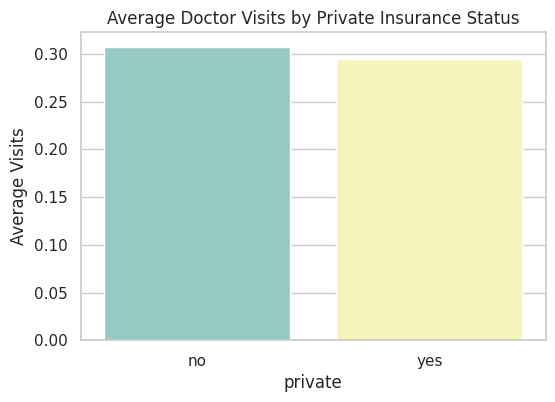

In [56]:
private_visits = df.groupby('private')['visits'].mean()
print(private_visits.round(3))

a = df[df['private'] == 'yes']['visits']
b = df[df['private'] == 'no']['visits']
t_stat, p_val = stats.ttest_ind(a, b, equal_var=False)
print(f"Welch t-test (private yes vs no): t = {t_stat:.2f}, p-value = {p_val:.4f}")

plt.figure(figsize=(6, 4))
sns.barplot(x=private_visits.index, y=private_visits.values, hue=private_visits.index, palette='Set3', legend=False)
plt.title('Average Doctor Visits by Private Insurance Status')
plt.ylabel('Average Visits')
plt.show()

In [57]:
df['income_q'] = pd.qcut(df['income_dollars'], 4, duplicates='drop')
print("Private insurance rate by income quartile:")
print(df.groupby('income_q', observed=True)['private'].apply(lambda x: (x == 'yes').mean()).round(3))

print("\nHealth score by insurance status (lower = healthier):")
print(df.groupby('private')['health'].mean().round(3))

print("\nRate of limiting chronic condition by insurance status:")
print(df.groupby('private')['lchronic'].apply(lambda x: (x == 'yes').mean()).round(3))

Private insurance rate by income quartile:
income_q
(-0.001, 2500.0]     0.275
(2500.0, 5500.0]     0.403
(5500.0, 9000.0]     0.547
(9000.0, 15000.0]    0.678
Name: private, dtype: float64

Health score by insurance status (lower = healthier):
private
no     1.313
yes    1.097
Name: health, dtype: float64

Rate of limiting chronic condition by insurance status:
private
no     0.129
yes    0.101
Name: lchronic, dtype: float64


Private insurance shows no visit difference (p = 0.56). The second table shows *why this might be*: private cover rises steeply with income (about 27% in the lowest quartile to 68% in the highest), and privately insured people report slightly better health. This is **consistent with** a selection effect, but it does not prove one.

##  Does Government Assistance Insurance Behave Differently?

                                                       No    Yes
freepoor (low-income free cover)                    0.308  0.158
freerepat (old age / disability / veteran free ...  0.258  0.467


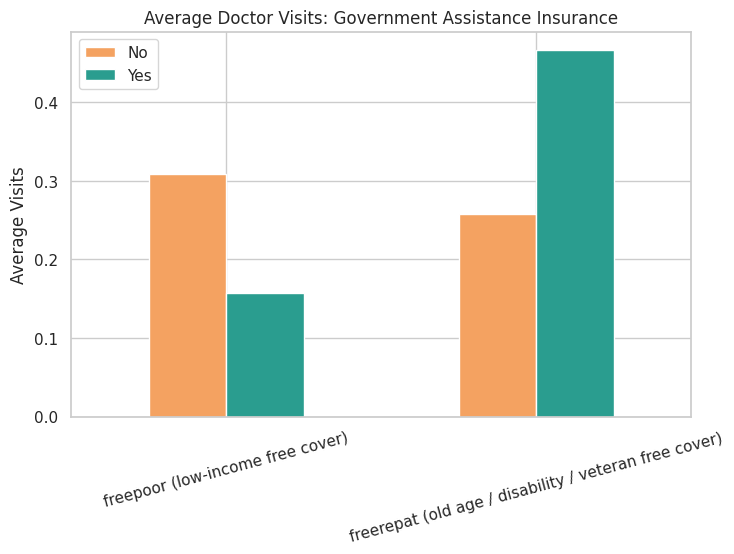

Welch t-test (freepoor): t = -3.12, p-value = 1.99e-03  (n yes = 222)
Welch t-test (freerepat): t = 6.67, p-value = 3.74e-11  (n yes = 1091)


In [58]:
gov_insurance = pd.DataFrame({
    'No': [df[df['freepoor'] == 'no']['visits'].mean(), df[df['freerepat'] == 'no']['visits'].mean()],
    'Yes': [df[df['freepoor'] == 'yes']['visits'].mean(), df[df['freerepat'] == 'yes']['visits'].mean()]
}, index=['freepoor (low-income free cover)', 'freerepat (old age / disability / veteran free cover)'])
print(gov_insurance.round(3))

gov_insurance.plot(kind='bar', figsize=(8, 5), color=['#f4a261', '#2a9d8f'])
plt.title('Average Doctor Visits: Government Assistance Insurance')
plt.ylabel('Average Visits')
plt.xticks(rotation=15)
plt.show()

for col in ['freepoor', 'freerepat']:
    a = df[df[col] == 'yes']['visits']
    b = df[df[col] == 'no']['visits']
    t_stat, p_val = stats.ttest_ind(a, b, equal_var=False)
    print(f"Welch t-test ({col}): t = {t_stat:.2f}, p-value = {p_val:.2e}  (n yes = {len(a)})")

### Who is in these groups?
The `freepoor` cover seem to visit less (0.16 vs 0.31). But this group is small (222 people) and young (average age 25). When I compare only people aged 30 or below, the difference is small and not significant (0.17 vs 0.22, p ≈ 0.4). So the low visits are mostly an age effect.

In [59]:
print(df.groupby(['freepoor'])[['age_years', 'income_dollars', 'health']].mean().round(1))
print()
print(df.groupby(['freerepat'])[['age_years', 'income_dollars', 'health']].mean().round(1))
print("\nShare with limiting chronic condition:")
print(df.groupby('freerepat')['lchronic_num'].mean().round(3))

          age_years  income_dollars  health
freepoor                                   
no             41.3          5957.5     1.2
yes            25.0          3014.0     1.8

           age_years  income_dollars  health
freerepat                                   
no              34.2          6597.6     1.1
yes             64.6          2953.5     1.5

Share with limiting chronic condition:
freerepat
no     0.090
yes    0.217
Name: lchronic_num, dtype: float64


### Age-controlled check for `freepoor`
The raw gap (0.16 vs 0.31 visits) largely reflects age: among people aged 30 or under, `freepoor` and others do not differ significantly (0.17 vs 0.22, p is about 0.4). In older age groups the `freepoor` counts (16, 12 and 4) are too small to conclude anything.

In [60]:
tab = df.groupby(['age_group', 'freepoor'], observed=True)['visits'].agg(['mean', 'count']).round(3)
print(tab)

young = df[df['age_years'] <= 30]
a = young[young['freepoor'] == 'yes']['visits']
b = young[young['freepoor'] == 'no']['visits']
t_stat, p_val = stats.ttest_ind(a, b, equal_var=False)
print(f"\nAge <= 30 only: freepoor mean = {a.mean():.3f} (n={len(a)}), others = {b.mean():.3f} (n={len(b)}), "
      f"Welch p-value = {p_val:.3f}")

                     mean  count
age_group freepoor              
19-30     no        0.220   2298
          yes       0.174    190
31-45     no        0.266    557
          yes       0.062     16
46-60     no        0.375    664
          yes       0.083     12
61-72     no        0.433   1449
          yes       0.000      4

Age <= 30 only: freepoor mean = 0.174 (n=190), others = 0.220 (n=2298), Welch p-value = 0.405


### Does the chronic-condition effect hold across insurance groups?
Roughly doubles for private yes/no (2.1x to 2.5x), is about 1.8x for `freerepat`, and is 1.6x within `freepoor`, where only 26 people have a limiting chronic condition, so that last figure is unreliable.

In [61]:
for col in ['private', 'freepoor', 'freerepat']:
    t = df.groupby([col, 'lchronic'])['visits'].agg(['mean', 'count']).round(3)
    print(t, "\n")

                   mean  count
private lchronic              
no      no        0.268   2518
        yes       0.575    374
yes     no        0.255   2067
        yes       0.649    231 

                    mean  count
freepoor lchronic              
no       no        0.267   4389
         yes       0.620    579
yes      no        0.148    196
         yes       0.231     26 

                     mean  count
freerepat lchronic              
no        no        0.231   3731
          yes       0.527    368
yes       no        0.396    854
          yes       0.722    237 



## Multivariate Analysis

### Pair plot: visits, age, reduced-activity days, health, by chronic status

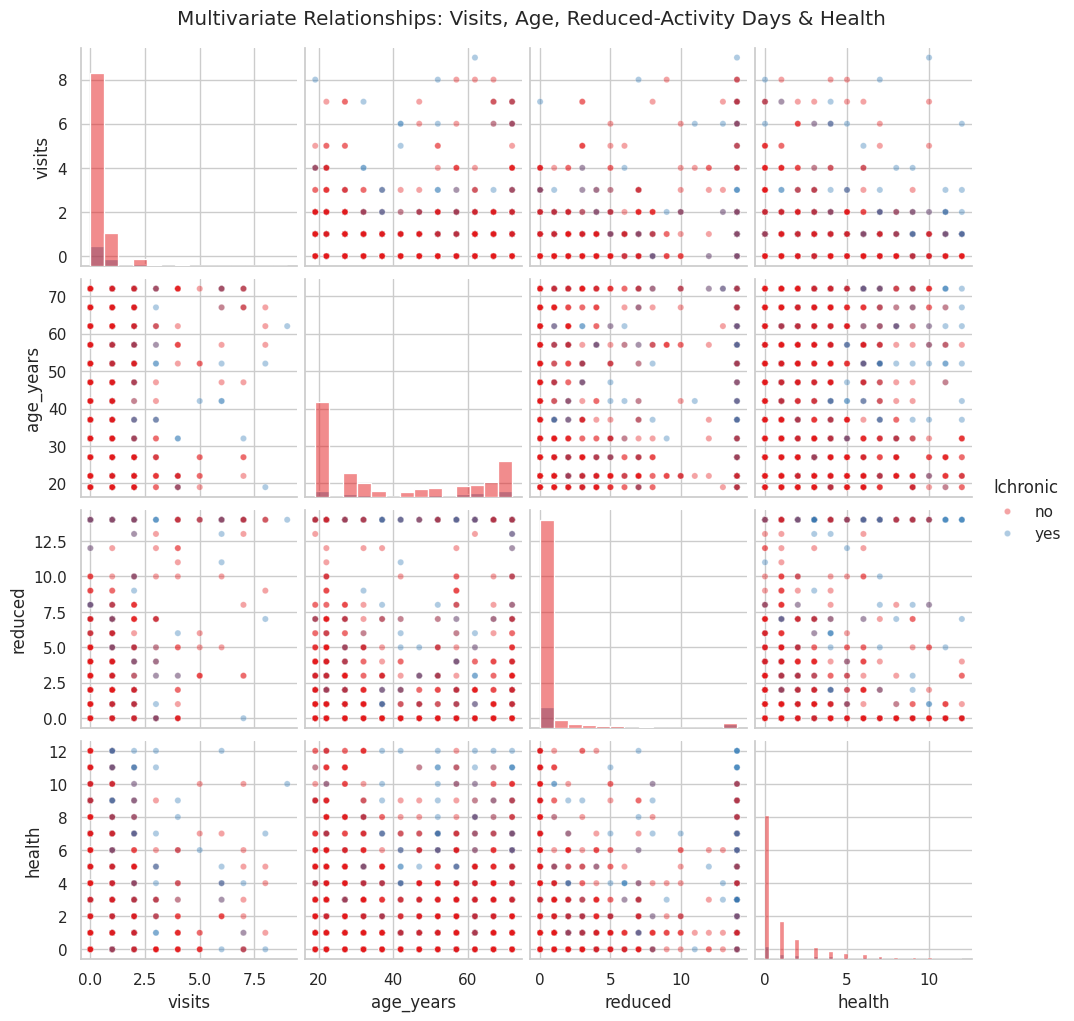

Group averages by chronic condition status:
          visits  age_years  reduced  health
lchronic                                    
no          0.26      39.74     0.63    1.07
yes         0.60      47.46     2.58    2.34


In [62]:
pair_cols = ['visits', 'age_years', 'reduced', 'health', 'lchronic']
sns.pairplot(df[pair_cols], hue='lchronic', palette='Set1', plot_kws={'alpha': 0.4, 's': 20}, diag_kind='hist')
plt.suptitle('Multivariate Relationships: Visits, Age, Reduced-Activity Days & Health', y=1.02)
plt.show()

print("Group averages by chronic condition status:")
print(df.groupby('lchronic')[['visits', 'age_years', 'reduced', 'health']].mean().round(2))

### Health score by chronic condition and visit status

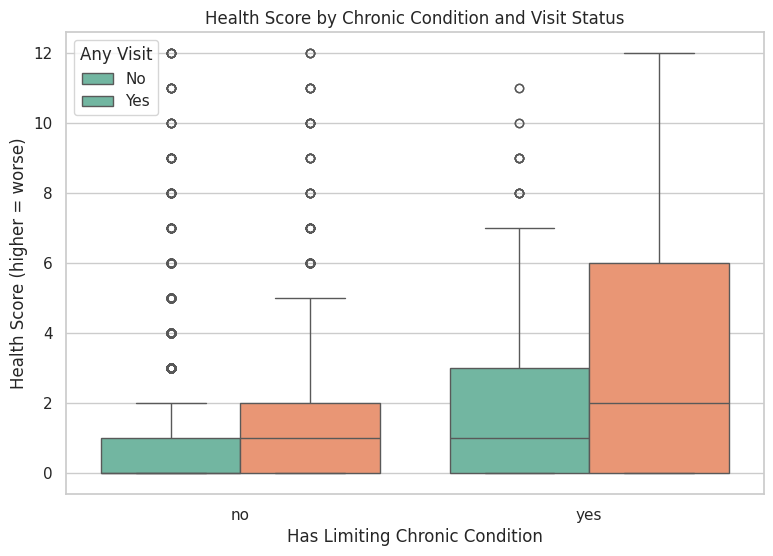

In [63]:
plt.figure(figsize=(9, 6))
sns.boxplot(x='lchronic', y='health', hue='any_visit', data=df, palette='Set2')
plt.title('Health Score by Chronic Condition and Visit Status')
plt.xlabel('Has Limiting Chronic Condition')
plt.ylabel('Health Score (higher = worse)')
plt.legend(title='Any Visit', labels=['No', 'Yes'])
plt.show()

### Age, visits and gender

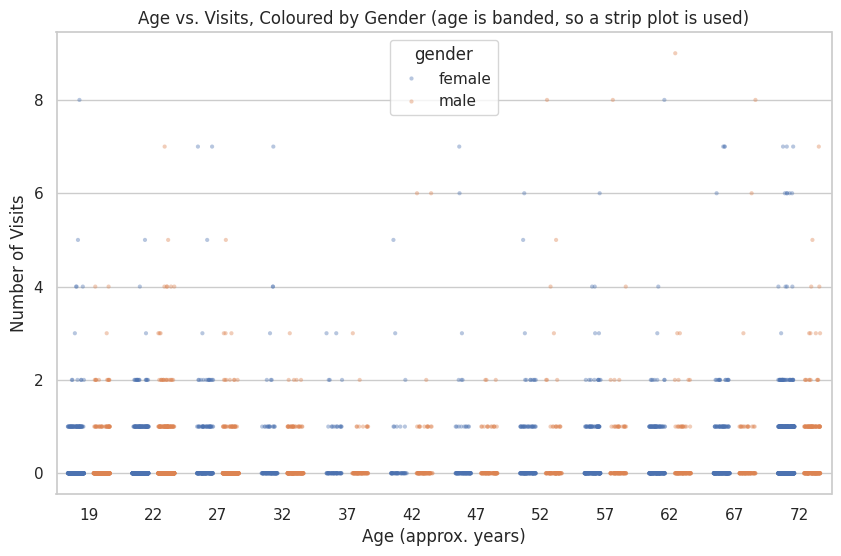

In [64]:
plt.figure(figsize=(10, 6))
sns.stripplot(x='age_years', y='visits', hue='gender', data=df, palette='deep', alpha=0.4, dodge=True, jitter=0.25, size=3)
plt.title('Age vs. Visits, Coloured by Gender (age is banded, so a strip plot is used)')
plt.xlabel('Age (approx. years)')
plt.ylabel('Number of Visits')
plt.show()

##  What Characterizes People Who Never Visit the Doctor?

                    age_years  income_dollars  illness  reduced  health
Zero Visits             39.03         5980.15     1.26     0.43    1.02
One or More Visits      46.97         5245.19     2.13     2.58    1.99


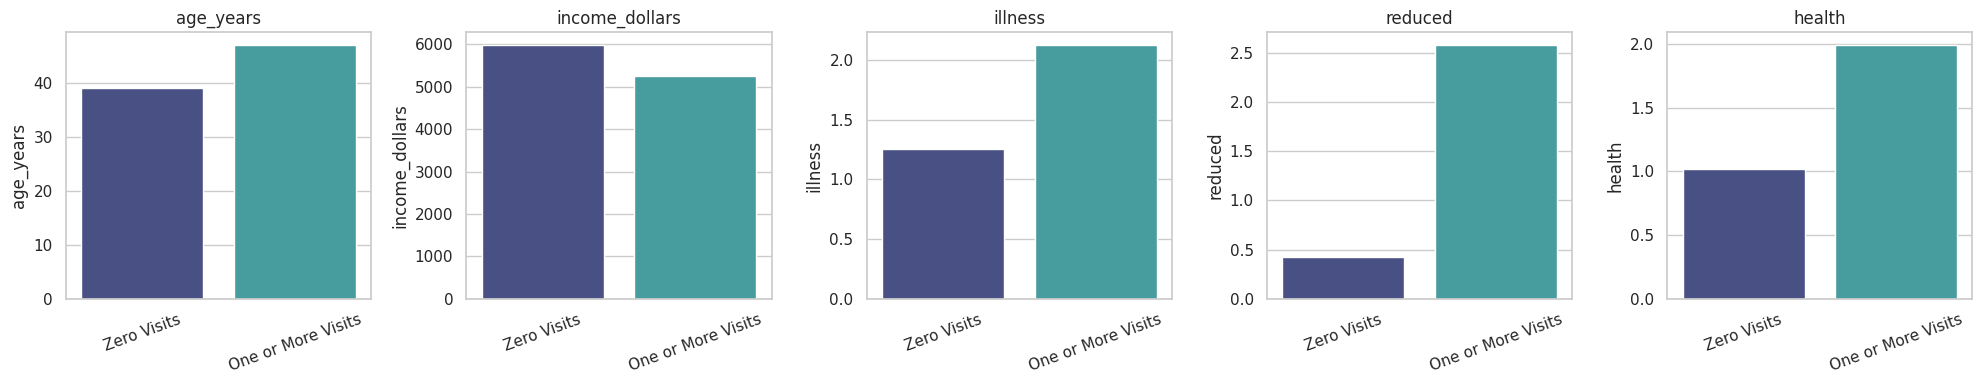


Chi-square test (lchronic vs any_visit): chi2 = 92.35, p-value = 7.27e-22


In [65]:
compare_cols = ['age_years', 'income_dollars', 'illness', 'reduced', 'health']
comparison = df.groupby('any_visit')[compare_cols].mean()
comparison.index = ['Zero Visits', 'One or More Visits']
print(comparison.round(2))

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, col in zip(axes, compare_cols):
    sns.barplot(x=comparison.index, y=comparison[col], hue=comparison.index, palette='mako', legend=False, ax=ax)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

chi2, p, dof, exp = stats.chi2_contingency(pd.crosstab(df['lchronic'], df['any_visit']))
print(f"\nChi-square test (lchronic vs any_visit): chi2 = {chi2:.2f}, p-value = {p:.2e}")

##  Unusual / Unexpected Patterns
- **Private insurance**:no effect on visits (p = 0.56). Private holders have higher income and slightly better health.

- **freepoor:** fewer visits, but mainly because this group is young.

- **Gender:** women visit more than men (0.36 vs 0.24), even within the same chronic-condition group.

- **Income:** very weak negative link with visits (r = -0.08).



##  Key Questions - Summary of Findings

| Question | Finding |
|---|---|
|Strongest predictor?|	Reduced-activity days (r = 0.42), then illness (0.22) and health score (0.19)|
|Gender?|	Women visit more (0.36 vs 0.24)|
|Age?|	Visits double from youngest to oldest group (0.22 to 0.43)|
|Chronic condition?	|About 2.3x more visits (0.60 vs 0.26)|
|Private insurance?|	No effect (p = 0.56)|
|Government insurance?|	`freerepat`: more visits (older group). `freepoor`: fewer, mostly due to age|
|Zero-visit people?	|Younger, fewer illnesses, fewer reduced-activity days, better health|

##  Limitations

- **Two-week recall window:** visit counts cover only two weeks, so people with infrequent but real health needs may appear as "zero visits" (about 80% of the sample).
- **Cross-sectional data:** all variables are measured at one point in time, so associations cannot be read as causation.
- **Self-reported measures:** health score, illness counts and chronic-condition flags are self-reported.
- **Confounding is only partly controlled:** most comparisons here are unadjusted. Age in particular drives the `freepoor` and `freerepat` differences. A regression model (e.g. Poisson or negative binomial) with all variables together would be the natural next step.
- **Small groups:** `freepoor` has only 222 people (26 with a limiting chronic condition), so subgroup results there are unstable.
- **No cost or geographic data:** reasons behind any access differences cannot be identified.
- **Banded variables:** `age` and `income` take only a handful of values (e.g. 12 age bands), so rescaled values are approximate and the age groups are uneven in size.

## Final Conclusion

- Health need is the main driver of doctor visits: people with more reduced-activity days, more illnesses or a limiting chronic condition visit more. Age and gender also matter, as older people and women visit more. Private insurance shows no effect, and the low visits of freepoor people are mostly due to their young age. These results are only comparisons without adjusting for other variables, so they do not prove cause and effect. A regression model would be the next step.